<a href="https://colab.research.google.com/github/GungunSinghal03/california-housing-regression/blob/main/linearregression__california.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=fetch_california_housing()

In [4]:
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [5]:
dataset=pd.DataFrame(df.data)

In [6]:
dataset.columns=df.feature_names

In [7]:
dataset.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [36]:
dataset['target'] = df.target
X = dataset.drop('target', axis=1)
Y = dataset['target']


In [37]:
Y

,target
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [38]:
#traintest split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size= 0.3,random_state=42)

In [39]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [40]:
Y_train

,target
7061,1.93800
14689,1.69700
17323,2.59800
10056,1.36100
15750,5.00001
...,...
11284,2.29200
11964,0.97800
5390,2.22100
860,2.83500


In [41]:
#linear regression implementation
#standardizing the problem-kyonki gradient descent hota h
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [42]:
X_train=scaler.fit_transform(X_train)

In [43]:
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>


In [44]:
X_test=scaler.transform(X_test)

In [45]:
#scaler.inverse_transform(X_train)-agr inverse dobara unfit and untransform karna h toh

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
#cross validation-mtlb data ko multiple m divide and then train and then avg of all those output just like random forest
from sklearn.model_selection import cross_val_score

In [48]:
regression=LinearRegression()
regression.fit(X_train,Y_train)


LinearRegression()

In [49]:
mse = cross_val_score(regression, X_train, Y_train,
                      scoring='neg_mean_squared_error',
                      cv=10)
#cv=cross value

In [50]:
print(np.mean(mse))

-0.5257104326777


In [51]:
#prediction
reg_pred = regression.predict(X_test)

In [52]:
reg_pred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133])

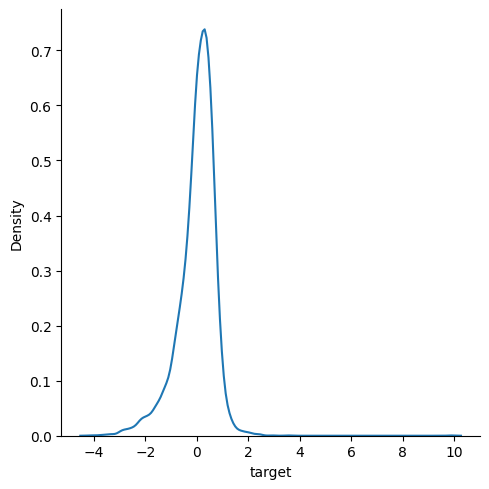

In [53]:
# to check our model with actual value(y_train)
import seaborn as sns
sns.displot(reg_pred-Y_test,kind='kde')

In [54]:
from sklearn.metrics import r2_score

In [55]:
score=r2_score(reg_pred,Y_test)

In [56]:
score


0.3451339380943961